In [1]:
# Design and implement a Convolutional Neural Network (CNN) for image classification using
# the Tomato or Soybean disease dataset.
# autotune cnn

In [2]:
!pip install keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]



In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import keras_tuner as kt

In [4]:
dataset_dir = "PlantVillage"

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 43445 images belonging to 2 classes.
Found 10860 images belonging to 2 classes.


In [6]:
print("Classes:", train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Classes: {'train': 0, 'val': 1}
Number of classes: 2
Training samples: 43445
Validation samples: 10860


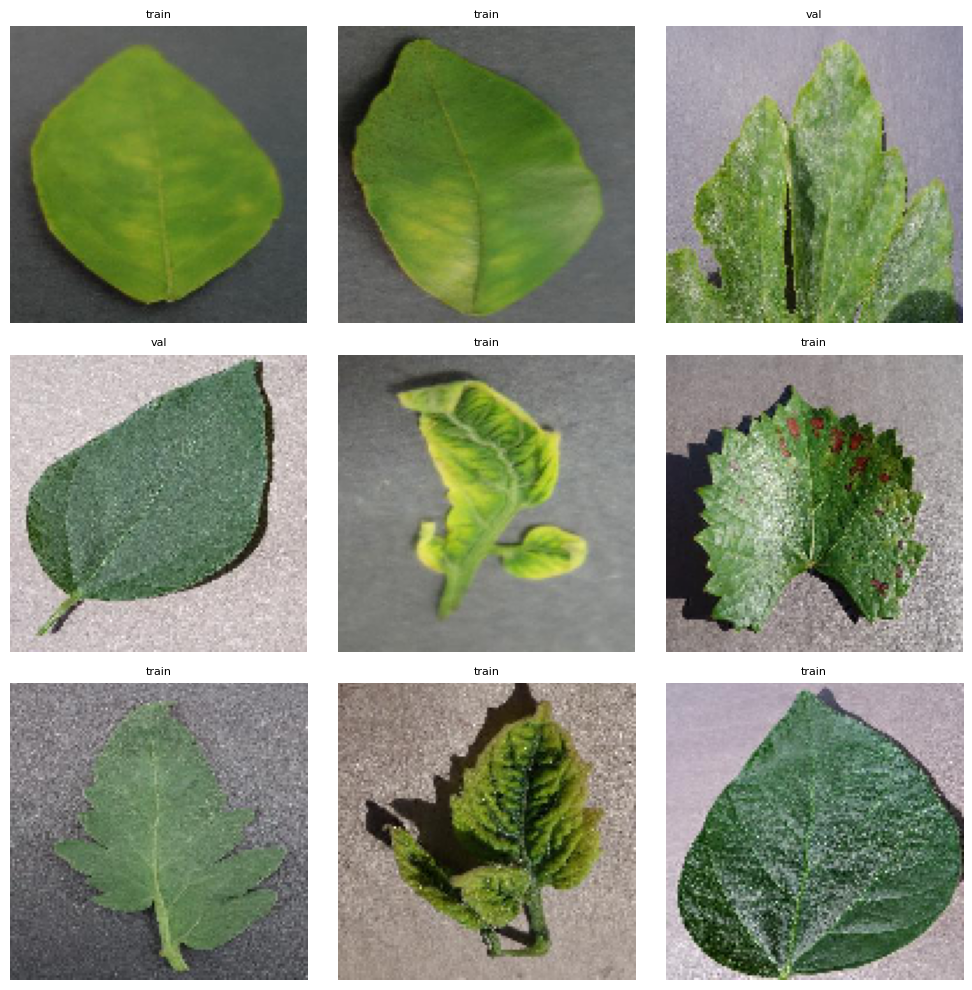

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_generator.class_indices.keys())[np.argmax(labels[i])], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

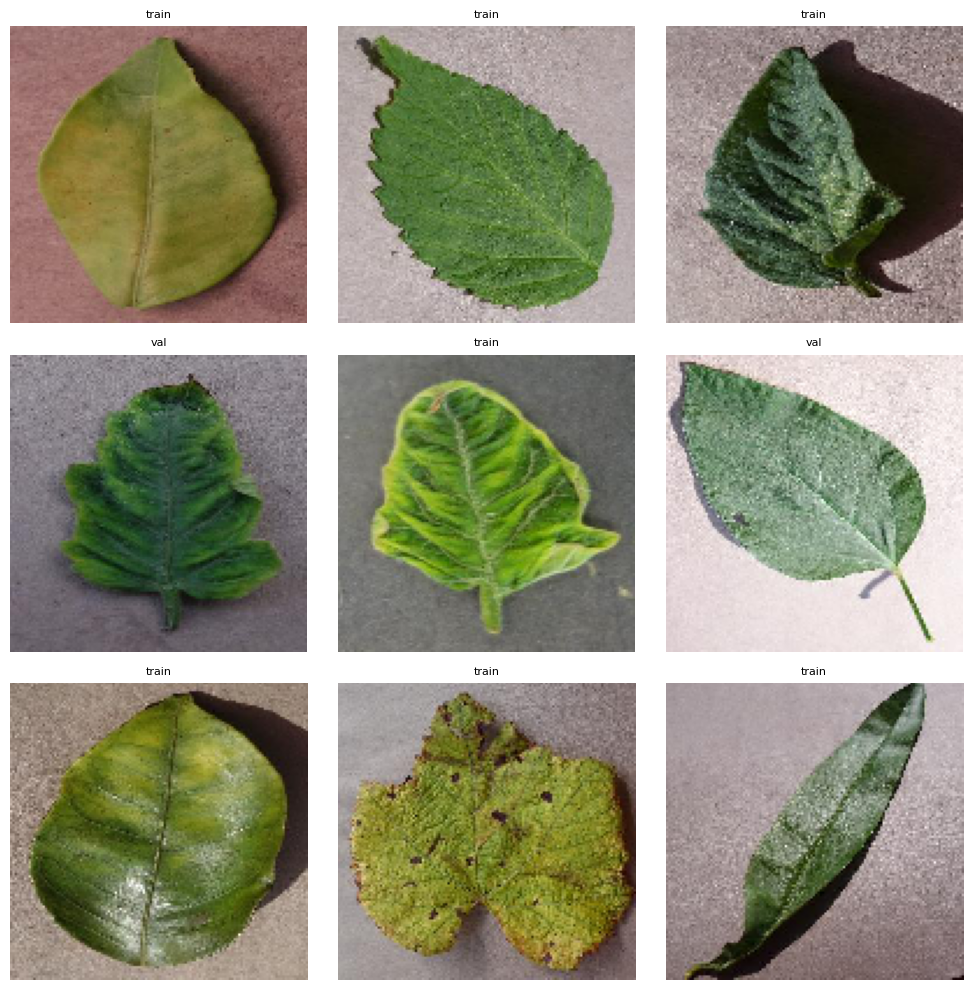

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_generator.class_indices.keys())[np.argmax(labels[i])], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

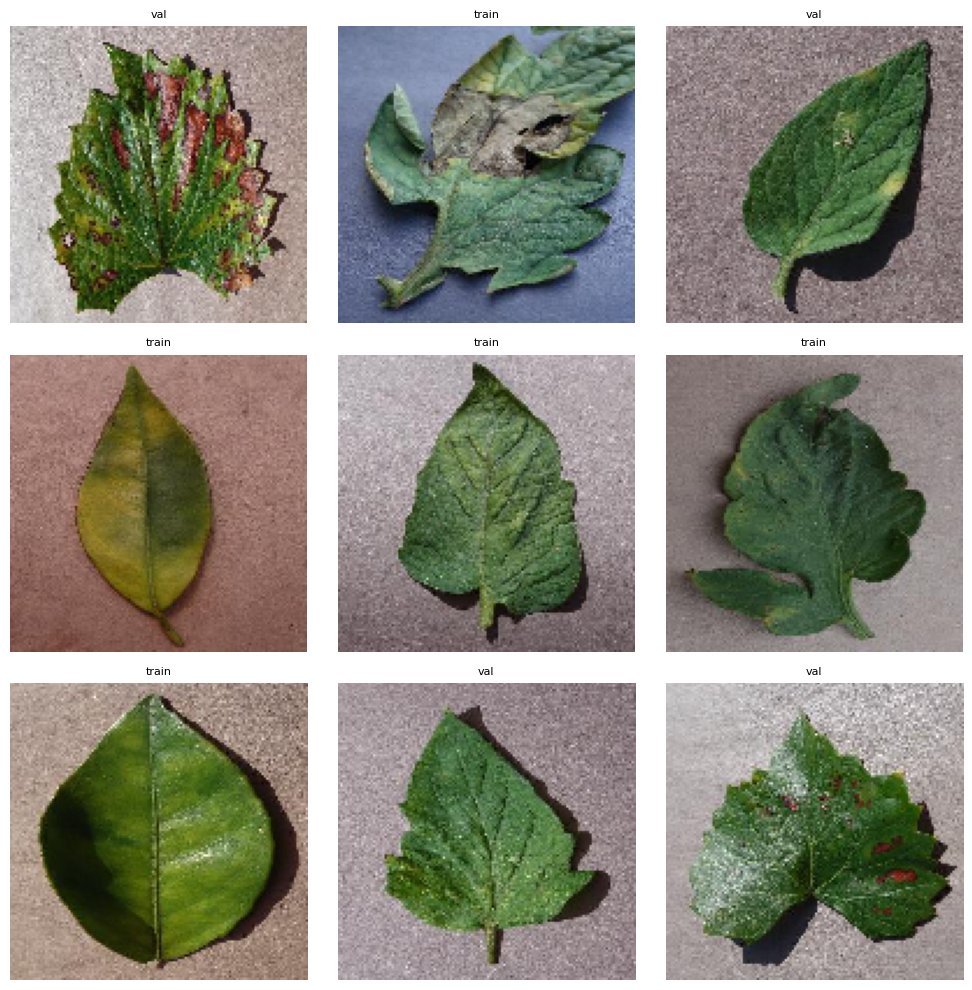

In [9]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_generator.class_indices.keys())[np.argmax(labels[i])], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
print("Class Names:")
print(train_generator.class_indices)

print("\nNumber of Classes:", train_generator.num_classes)
print("Training Images:", train_generator.samples)
print("Validation Images:", val_generator.samples)

Class Names:
{'train': 0, 'val': 1}

Number of Classes: 2
Training Images: 43445
Validation Images: 10860


In [11]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [12]:
def build_model(hp):

    model = Sequential()

    model.add(
        Conv2D(
            filters=hp.Choice("filters1", [32, 64]),
            kernel_size=(3,3),
            activation='relu',
            input_shape=(128,128,3)
        )
    )

    model.add(MaxPooling2D())

    model.add(
        Conv2D(
            filters=hp.Choice("filters2", [64,128]),
            kernel_size=(3,3),
            activation='relu'
        )
    )

    model.add(MaxPooling2D())

    model.add(
        Conv2D(
            filters=hp.Choice("filters3",[128,256]),
            kernel_size=(3,3),
            activation='relu'
        )
    )

    model.add(MaxPooling2D())

    model.add(Flatten())

    model.add(
        Dense(
            units=hp.Choice("dense_units",[128,256,512]),
            activation='relu'
        )
    )

    model.add(
        Dropout(
            hp.Float("dropout",0.2,0.5,step=0.1)
        )
    )

    model.add(Dense(train_generator.num_classes,activation='softmax'))

    model.compile(
        optimizer=Adam(
            hp.Choice("learning_rate",[1e-2,1e-3,1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model